# LogiSense-AI - Exploratory Data Analysis

## `01_eda.ipynb`

Explores the **real** APL Logistics dataset (`data/raw/APL_Logistics - APL_Logistics.csv`)
and documents the patterns that drive the modeling pipeline in
`backend/ml/preprocessing.py`.

> **Leakage warning:** we predict `Late_delivery_risk` **before** delivery. Columns
> such as `Delivery Status`, `Days for shipping (real)` and all realized financial
> fields reproduce the outcome after the fact and are therefore **excluded** from
> every model. They appear in this EDA for understanding only.


In [1]:
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Robustly locate the repository root from the notebook's working directory.
REPO = Path().resolve()
for _ in range(3):
    if (REPO / "data" / "raw").exists():
        break
    REPO = REPO.parent

df = pd.read_csv(REPO / "data/raw/APL_Logistics - APL_Logistics.csv",
                 encoding="utf-8", low_memory=False)

# Consistent styling for all figures in this notebook.
COLOR_LATE   = "#C94C4C"
COLOR_ONTIME = "#4C7C8A"
ACCENT       = "#2F6BB0"
plt.rcParams.update({
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110,
})

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
df.head()

Loaded 180,519 rows x 40 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


## 1. Data quality - missing values & duplicate rows

In [2]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "  (none - fully complete)")

dupes = df.duplicated().sum()
print(f"\nExact duplicate rows: {dupes:,}")

Missing values per column:
Customer Lname      8
Customer Zipcode    3
dtype: int64



Exact duplicate rows: 0


## 2. Target distribution

`Late_delivery_risk` = 1 if the shipment arrived after the promised date.
Slightly **imbalanced toward late** (54.8%).

                    n_orders  percent
Late_delivery_risk                   
0                      81542    0.452
1                      98977    0.548


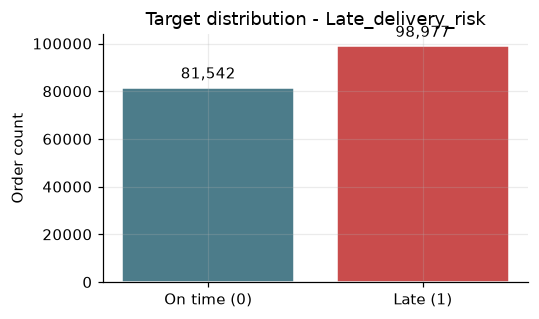

In [3]:
vc = df["Late_delivery_risk"].value_counts().sort_index()
dist = vc.to_frame(name="n_orders")
dist["percent"] = (dist / dist.sum()).round(3)
print(dist)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["On time (0)", "Late (1)"], vc.values,
              color=[COLOR_ONTIME, COLOR_LATE], edgecolor="white")
for b in bars:
    ax.annotate(f"{b.get_height():,}", xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 6), textcoords="offset points", ha="center")
ax.set_title("Target distribution - Late_delivery_risk")
ax.set_ylabel("Order count")
plt.tight_layout(); plt.show()

## 3. Scheduled shipping days vs target

`Days for shipment (scheduled)` is the promised lead time and the **only
pre-delivery numeric with real signal** - shorter promises run late more often.

                               late_rate  n_orders
Days for shipment (scheduled)                     
0                               0.457430      9737
1                               0.953225     27814
2                               0.766328     35216
4                               0.380717    107752


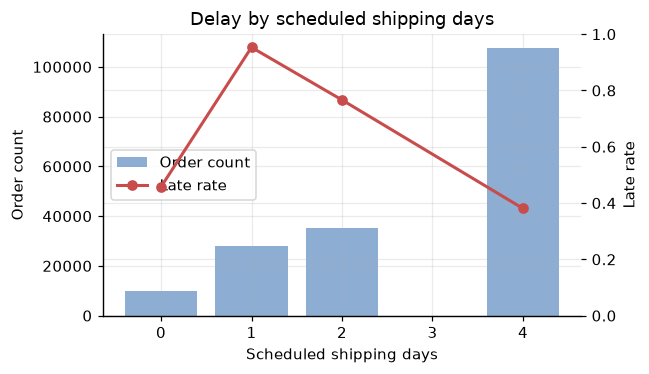

In [4]:
days = df.groupby("Days for shipment (scheduled)")["Late_delivery_risk"].agg(["mean", "count"])
days.columns = ["late_rate", "n_orders"]
print(days)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax2 = ax.twinx()
ax.bar(days.index, days["n_orders"], color=ACCENT, alpha=0.55, label="Order count")
ax2.plot(days.index, days["late_rate"], color=COLOR_LATE, marker="o", linewidth=2, label="Late rate")
ax.set_xlabel("Scheduled shipping days"); ax.set_ylabel("Order count")
ax2.set_ylabel("Late rate"); ax2.set_ylim(0, 1)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center left")
ax.set_title("Delay by scheduled shipping days")
plt.tight_layout(); plt.show()

## 4. Shipping mode vs target

`Standard Class` should look the worst - it carries the longest promised windows.

                late_rate  n_orders
Shipping Mode                      
Standard Class   0.380717    107752
Same Day         0.457430      9737
Second Class     0.766328     35216
First Class      0.953225     27814


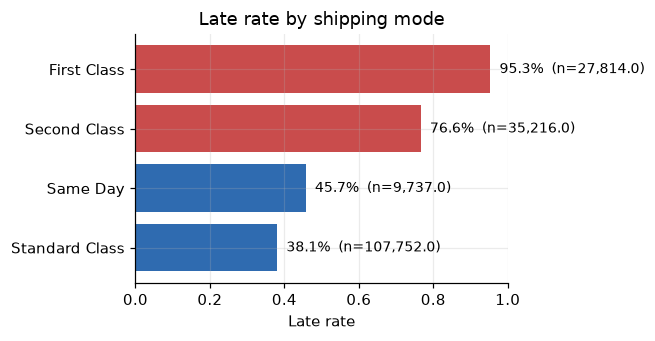

In [5]:
mode = df.groupby("Shipping Mode")["Late_delivery_risk"].agg(["mean", "count"]).sort_values("mean")
mode.columns = ["late_rate", "n_orders"]
print(mode)

fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.barh(mode.index, mode["late_rate"],
               color=[COLOR_LATE if r > 0.5 else ACCENT for r in mode["late_rate"]])
for b, (_, row) in zip(bars, mode.iterrows()):
    ax.annotate(f"{row['late_rate']:.1%}  (n={row['n_orders']:,})",
                xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_xlim(0, 1)
ax.set_title("Late rate by shipping mode")
ax.set_xlabel("Late rate")
plt.tight_layout(); plt.show()

## 5. Market and Order Region vs target

Geography is coarse in the model (`Market` has 5 values, `Order Region` has 23).

Market:
               late_rate  n_orders
Market                           
LATAM          0.543552     51594
Africa         0.545893     11614
USCA           0.548006     25799
Pacific Asia   0.550460     41260
Europe         0.552078     50252 

Order Region (top 12 by volume):
                  late_rate  n_orders
Order Region                        
Caribbean         0.530777      8318
West of USA       0.539597      7993
Oceania           0.540205     10148
Northern Europe   0.540441      9792
South America     0.543087     14935
Eastern Asia      0.543269      7280
Southern Europe   0.543845      9431
Central America   0.547546     28341
Southeast Asia    0.555299      9539
East of USA       0.556616      6915
Western Europe    0.558486     27109
South Asia        0.562670      7731


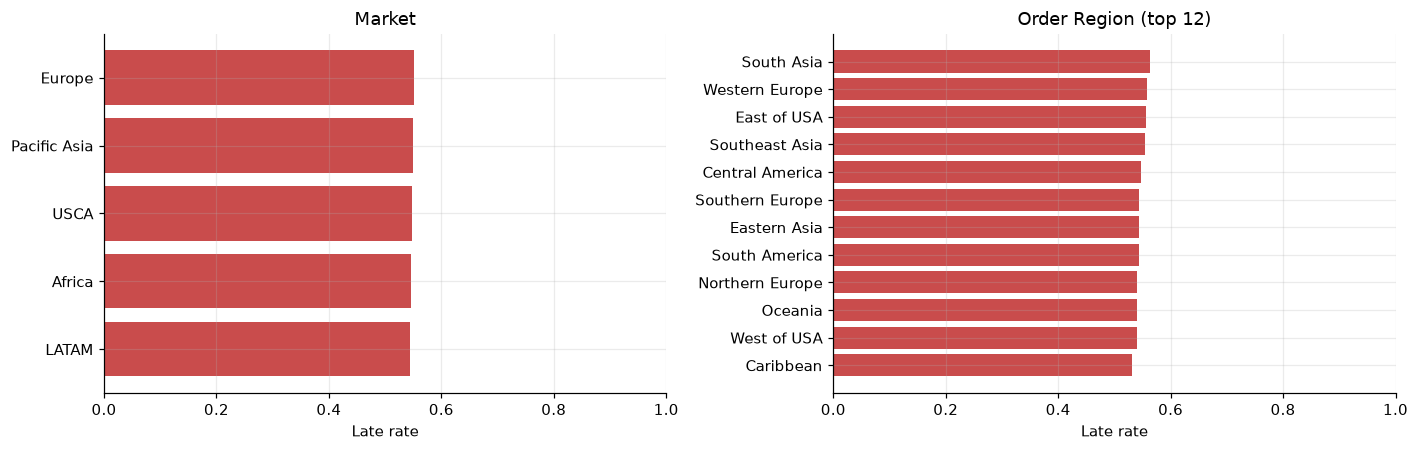

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

mk = df.groupby("Market")["Late_delivery_risk"].agg(["mean", "count"]).sort_values("mean")
mk.columns = ["late_rate", "n_orders"]
print("Market:\n", mk, "\n")
axes[0].barh(mk.index, mk["late_rate"],
             color=[COLOR_LATE if r > 0.5 else ACCENT for r in mk["late_rate"]])
axes[0].set_title("Market"); axes[0].set_xlabel("Late rate"); axes[0].set_xlim(0, 1)

reg = (df.groupby("Order Region")["Late_delivery_risk"]
         .agg(["mean", "count"]).sort_values("count", ascending=False).head(12)
         .sort_values("mean"))
reg.columns = ["late_rate", "n_orders"]
print("Order Region (top 12 by volume):\n", reg)
axes[1].barh(reg.index, reg["late_rate"],
             color=[COLOR_LATE if r > 0.5 else ACCENT for r in reg["late_rate"]])
axes[1].set_title("Order Region (top 12)"); axes[1].set_xlabel("Late rate"); axes[1].set_xlim(0, 1)

plt.tight_layout(); plt.show()

## 6. Product, Category and Department patterns

`Category Name` (50) and `Department Name` (11) are model features;
`Product Name` (118) is dropped as redundant with its category/department.

Top 10 categories by volume:
                       late_rate  n_orders
Category Name                            
Cleats                 0.549713     24551
Men's Footwear         0.544862     22246
Women's Apparel        0.545567     21035
Indoor/Outdoor Games   0.547466     19298
Fishing                0.549264     17325
Water Sports           0.548069     15540
Camping & Hiking       0.545342     13729
Cardio Equipment       0.544967     12487
Shop By Sport          0.551529     10984
Electronics            0.560837      3156


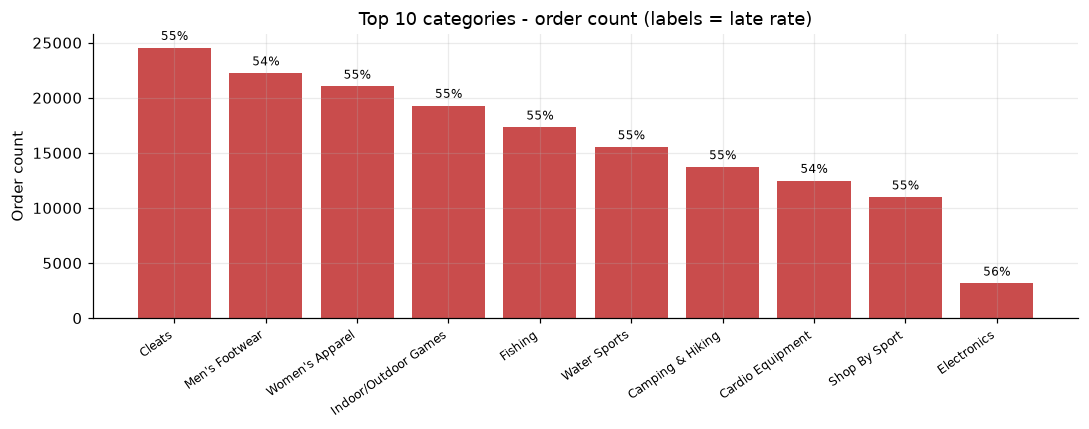

In [7]:
cat = df.groupby("Category Name")["Late_delivery_risk"].agg(["mean", "count"]).sort_values("count", ascending=False)
cat.columns = ["late_rate", "n_orders"]
print("Top 10 categories by volume:\n", cat.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
c = cat.head(10)
bars = ax.bar(range(len(c)), c["n_orders"],
              color=[COLOR_LATE if r > 0.5 else ACCENT for r in c["late_rate"]])
ax.set_xticks(range(len(c))); ax.set_xticklabels(c.index, rotation=35, ha="right", fontsize=8)
for b, (_, row) in zip(bars, c.iterrows()):
    ax.annotate(f"{row['late_rate']:.0%}", xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", fontsize=8)
ax.set_title("Top 10 categories - order count (labels = late rate)")
ax.set_ylabel("Order count")
plt.tight_layout(); plt.show()

                   late_rate  n_orders
Department Name                       
Discs Shop          0.544423      2026
Footwear            0.547263     14525
Apparel             0.547471     48998
Fan Shop            0.547748     66861
Golf                0.547803     33220
Technology          0.550171      1465
Outdoors            0.554925      9686
Fitness             0.555466      2479
Health and Beauty   0.558011       362
Book Shop           0.565432       405
Pet Shop            0.589431       492


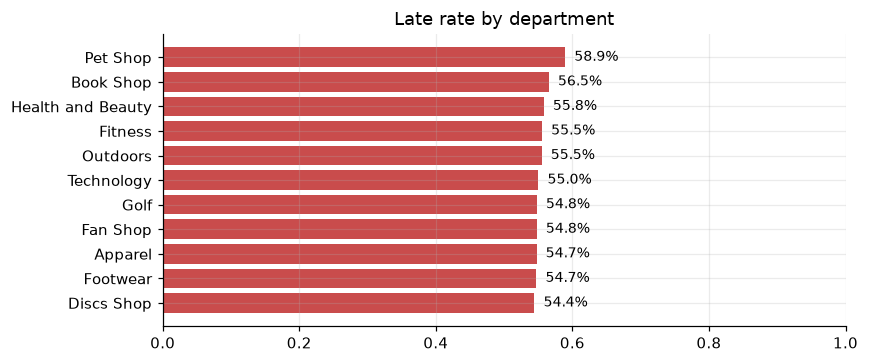

In [8]:
dep = df.groupby("Department Name")["Late_delivery_risk"].agg(["mean", "count"]).sort_values("mean")
dep.columns = ["late_rate", "n_orders"]
print(dep)

fig, ax = plt.subplots(figsize=(8, 3.4))
colors = [COLOR_LATE if r > 0.5 else ACCENT for r in dep["late_rate"]]
ax.barh(dep.index, dep["late_rate"], color=colors)
for i, (_, row) in enumerate(dep.iterrows()):
    ax.annotate(f"{row['late_rate']:.1%}", xy=(row["late_rate"], i),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_xlim(0, 1)
ax.set_title("Late rate by department")
plt.tight_layout(); plt.show()

In [9]:
prod = df.groupby("Product Name")["Late_delivery_risk"].agg(["mean", "count"]).sort_values("count", ascending=False)
prod.columns = ["late_rate", "n_orders"]
print("Top 10 products by volume:\n", prod.head(10))

Top 10 products by volume:
                                                late_rate  n_orders
Product Name                                                      
Perfect Fitness Perfect Rip Deck                0.549582     24515
Nike Men's CJ Elite 2 TD Football Cleat         0.544862     22246
Nike Men's Dri-FIT Victory Golf Polo            0.545567     21035
O'Brien Men's Neoprene Life Vest                0.547466     19298
Field & Stream Sportsman 16 Gun Fire Safe       0.549264     17325
Pelican Sunstream 100 Kayak                     0.547871     15500
Diamondback Women's Serene Classic Comfort Bi   0.545342     13729
Nike Men's Free 5.0+ Running Shoe               0.544745     12169
Under Armour Girls' Toddler Spine Surge Runni   0.552416     10617
Fighting video games                            0.542959       838


## 7. Customer segment and geography (states)

In [10]:
seg = df.groupby("Customer Segment")["Late_delivery_risk"].agg(["mean", "count"]).sort_values("mean")
seg.columns = ["late_rate", "n_orders"]
print(seg)

state = (df.groupby("Customer State")["Late_delivery_risk"]
          .agg(["mean", "count"]).sort_values("count", ascending=False).head(10)
          .sort_values("mean"))
state.columns = ["late_rate", "n_orders"]
print("\nTop 10 states by volume:\n", state)

                  late_rate  n_orders
Customer Segment                     
Corporate          0.547227     54789
Consumer           0.548084     93504
Home Office        0.550704     32226



Top 10 states by volume:
                 late_rate  n_orders
Customer State                     
NJ               0.525541      3191
MI               0.535226      3804
PA               0.535826      3824
NY               0.539154     11327
FL               0.539223      5456
PR               0.547634     69373
TX               0.552345      9103
OH               0.552381      4095
CA               0.553673     29223
IL               0.563884      7631


## 8. Numeric distributions & outliers

Financial fields appear here only for completeness - they are **excluded**
from every model (realized after delivery, ~zero signal).

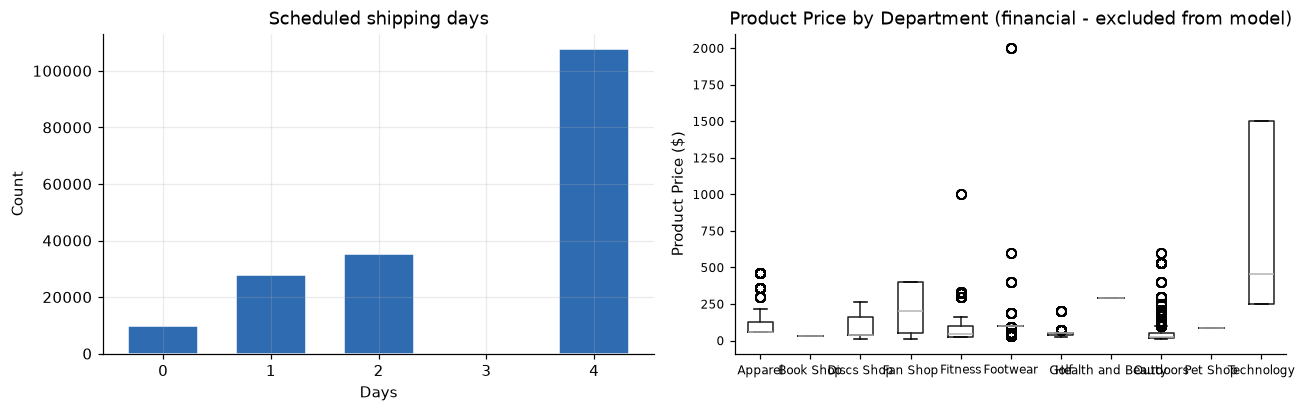

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Days for shipment (scheduled)"],
             bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
             color=ACCENT, edgecolor="white", rwidth=0.65)
axes[0].set_title("Scheduled shipping days")
axes[0].set_xlabel("Days"); axes[0].set_ylabel("Count")

order = df.groupby("Department Name")["Product Price"].median().sort_values(ascending=False).index
df.boxplot(column="Product Price", by="Department Name", grid=False, ax=axes[1], vert=True,
           fontsize=8)
axes[1].set_title("Product Price by Department (financial - excluded from model)")
axes[1].set_xlabel(""); axes[1].set_ylabel("Product Price ($)")

plt.suptitle(""); plt.tight_layout(); plt.show()

In [12]:
neg = df[df["Order Item Profit Ratio"] < 0]
print(f"Rows with negative profit ratio: {len(neg):,} ({len(neg)/len(df):.2%})")
if len(neg):
    print("Min:", round(neg["Order Item Profit Ratio"].min(), 3),
          "| median of negatives:", round(neg["Order Item Profit Ratio"].median(), 3))
print("-> financial field, realized after delivery, ~zero signal: excluded from features.")

Rows with negative profit ratio: 33,784 (18.71%)
Min: -2.75 | median of negatives: -0.38
-> financial field, realized after delivery, ~zero signal: excluded from features.


## 9. Data leakage exhibit - why columns are excluded

This section **proves**, at the data level, that two columns reproduce the target.

In [13]:
ct = pd.crosstab(df["Delivery Status"], df["Late_delivery_risk"])
print("=== Crosstab: Delivery Status x Late_delivery_risk ===\n", ct)
late_status = df["Delivery Status"].eq("Late delivery")
print(f"\nRows with 'Late delivery' status : {late_status.sum():,}")
print(f"Rows with target == 1            : {(df['Late_delivery_risk'] == 1).sum():,}")
print("-> identical sets: Delivery Status is the target in disguise (excluded).")

=== Crosstab: Delivery Status x Late_delivery_risk ===
 Late_delivery_risk      0      1
Delivery Status                 
Advance shipping    41592      0
Late delivery           0  98977
Shipping canceled    7754      0
Shipping on time    32196      0

Rows with 'Late delivery' status : 98,977
Rows with target == 1            : 98,977
-> identical sets: Delivery Status is the target in disguise (excluded).


In [14]:
gap = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]
gap_rate = df.groupby(gap)["Late_delivery_risk"].agg(["mean", "count"])
gap_rate.columns = ["late_rate", "n_orders"]
print("=== (real - scheduled) days gap vs late rate ===\n", gap_rate)
print("\n-> 'real' is only known after delivery; it already CONTAINS the delay (excluded).")

=== (real - scheduled) days gap vs late rate ===
     late_rate  n_orders
-2   0.000000     21666
-1   0.000000     21700
 0   0.000000     33753
 1   0.955645     60647
 2   0.959363     28718
 3   0.960295      7052
 4   0.959043      6983

-> 'real' is only known after delivery; it already CONTAINS the delay (excluded).


## 10. Numeric correlations with the target

Point-biserial correlations. `Days for shipping (real)` is strongest - and it
is the outcome itself. Every excluded financial field shows ~0.00. The single
*usable* numeric is `Days for shipment (scheduled)` (r = -0.37).

In [15]:
corr_cols = [c for c in df.select_dtypes(include="number").columns]
corr = df[corr_cols].corrwith(df["Late_delivery_risk"]).sort_values(ascending=False)
print(corr.round(4))

Late_delivery_risk               1.0000
Days for shipping (real)         0.4014
Customer Zipcode                 0.0031
Category Id                      0.0018
Customer Id                      0.0015
Order Customer Id                0.0015
Department Id                    0.0011
Latitude                         0.0007
Order Item Discount Rate         0.0004
Order Item Quantity             -0.0001
Order Item Discount             -0.0007
Longitude                       -0.0019
Order Item Product Price        -0.0022
Product Price                   -0.0022
Order Item Profit Ratio         -0.0023
Sales                           -0.0036
Benefit per order               -0.0037
Order Profit Per Order          -0.0037
Sales per customer              -0.0038
Order Item Total                -0.0038
Days for shipment (scheduled)   -0.3694
dtype: float64


## 11. Key findings & next steps

**Patterns that help prediction (all available pre-delivery):**
- `Days for shipment (scheduled)` - the strongest usable signal: shorter promise -> higher late rate.
- `Shipping Mode` - `Standard Class` is the worst performer within a small spread.
- `Market` / `Order Region` - consistent, coarse geographic variation.
- `Department Name` / `Category Name` - mild but stable differences across product families.

**Patterns with ~no signal:**
- All financial/profit columns (|r| < 0.01) - also realized only after delivery.

**Leakage proven (excluded from features):**
- `Delivery Status` is a 1:1 mirror of `Late_delivery_risk`.
- `Days for shipping (real)` == the delay measure itself.

**What happens next:**
1. `backend/ml/preprocessing.py` enforces these exclusions and saves stratified
   train/test splits + a reusable fitted pipeline.
2. Model training comes after this notebook (not yet).
3. The frontend dashboard comes last.
